# EPIC Array DNA Methylation: Epigenetic Aging Clock Benchmarking

---

## Overview

This notebook applies **8 epigenetic aging clocks** to two curated human blood methylation datasets and produces six visualizations benchmarking clock performance across datasets.

---

## Background: Epigenetic Aging Clocks

DNA methylation at CpG sites changes systematically with age. Epigenetic clocks are regression models trained on these methylation patterns to predict biological age. Different clocks were built to predict different outcomes:

| Clock | Year | Trained To Predict |
|---|---|---|
| Horvath v1 | 2013 | Chronological age across 51 tissue types |
| Hannum | 2013 | Chronological age in whole blood |
| PhenoAge | 2018 | Phenotypic/biological age from clinical biomarkers |
| GrimAge V1 | 2019 | Mortality and lifespan |
| GrimAge V2 | 2022 | Improved mortality prediction |
| DunedinPACE | 2022 | Pace of biological aging (not an age; ~1.0 = average rate) |
| YingDamAge | 2024 | Cumulative DNA damage accumulation |
| YingCausAge | 2024 | Causal biological aging signal |

---

## Datasets

The two datasets were selected for their small memory footprint and strong biological relevance to aging. The original large datasets (GSE40279: 656 samples, GSE51032: 845 samples) routinely crash Colab by exhausting session RAM. These replacements are biologically equivalent for benchmarking purposes and load reliably:

| Dataset | GEO Accession | Array | Samples | Description |
|---|---|---|---|---|
| Dataset 1 | GSE30870 | Illumina 450K | 40 | Whole blood from newborns and nonagenarians; extreme age contrast (~0-100 years) |
| Dataset 2 | GSE85311 | Illumina 450K | 38 | PBMCs from young sedentary, older sedentary and older exercise-trained adults |

---

> Run cells sequentially from top to bottom. Each cell depends on variables defined in the cells above it.

## Step 1: Install biolearn

The `biolearn` package provides:
- `DataLibrary`: downloads and parses curated GEO methylation datasets
- `ModelGallery`: provides pre-trained aging clock models with a uniform `.predict()` interface

Installation typically takes under 60 seconds.

In [ ]:
!pip install biolearn -q
print("biolearn installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 22.7 MB/s eta 0:00:00
biolearn installed.


## Step 2: Import Libraries

- `pandas` and `numpy`: data handling and numerical operations
- `matplotlib` and `seaborn`: visualization
- `DataLibrary` and `ModelGallery`: biolearn data and model interfaces

`warnings.filterwarnings('ignore')` suppresses non-critical deprecation messages.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from biolearn.data_library import DataLibrary
from biolearn.model_gallery import ModelGallery

print("All libraries imported.")

All libraries imported.


## Step 3: Load Both Datasets

### Dataset 1: GSE30870 -- Newborns and Nonagenarians
Compares DNA methylomes of newborns and nonagenarians (n=40). This extreme age contrast (0-100 years) provides the clearest possible test of whether a clock can track aging across the full human lifespan.

### Dataset 2: GSE85311 -- Aging and Exercise in PBMCs
Compares PBMCs from younger sedentary subjects, older sedentary subjects, and older aerobically trained subjects (n=38). This dataset introduces a lifestyle variable alongside chronological age, allowing assessment of whether clocks detect biological age differences driven by exercise rather than calendar age alone.

### What is loaded
Each dataset has two components:
- `.dnam`: beta values (rows = CpG sites, columns = samples), ranging 0-1
- `.metadata`: sample-level information including chronological age

In [ ]:
library = DataLibrary()

print("Loading Dataset 1: GSE30870 (Newborns and Nonagenarians)...")
dataset1 = library.get("GSE30870").load()
print(f"  Samples   : {dataset1.metadata.shape[0]}")
print(f"  CpG sites : {dataset1.dnam.shape[0]}")
print(f"  Age range : {dataset1.metadata['age'].min():.1f} - {dataset1.metadata['age'].max():.1f} years")

print("\nLoading Dataset 2: GSE85311 (Aging and Exercise in PBMCs)...")
dataset2 = library.get("GSE85311").load()
print(f"  Samples   : {dataset2.metadata.shape[0]}")
print(f"  CpG sites : {dataset2.dnam.shape[0]}")
print(f"  Age range : {dataset2.metadata['age'].min():.1f} - {dataset2.metadata['age'].max():.1f} years")

print("\nBoth datasets loaded successfully.")

Loading Dataset 1: GSE30870 (Newborns and Nonagenarians)...
  Samples   : 40
  CpG sites : 485577
  Age range : 89.0 - 103.0 years

Loading Dataset 2: GSE85311 (Aging and Exercise in PBMCs)...
  Samples   : 38
  CpG sites : 450855
  Age range : 20.0 - 68.0 years

Both datasets loaded successfully.


## Step 4: Define the 8 Aging Clocks and Run All Predictions

### How prediction works
Each clock is a regression model. `ModelGallery.get(name)` retrieves the pre-trained model weights. `.predict(dataset)` extracts the required CpG sites, applies the coefficients, and returns a predicted value aligned to the sample index.

### Error handling
Some clocks require CpG sites that may be absent from a given array. The `try/except` block catches these failures and fills the column with `NaN` so all downstream visualization continues to work on whatever data is available.

### Note on DunedinPACE
DunedinPACE outputs a pace-of-aging score (not years). A value of 1.0 represents the population average rate of aging. Its scatter plot and deviation values will therefore look different from all other clocks -- this is expected and interpretively meaningful, not an error.

In [ ]:
gallery = ModelGallery()

CLOCK_NAMES = [
    "Horvathv1",
    "Hannum",
    "PhenoAge",
    "GrimAgeV1",
    "GrimAgeV2",
    "DunedinPACE",
    "YingDamAge",
    "YingCausAge"
]

def run_clocks(dataset, label):
    results = {"Chronological_Age": dataset.metadata["age"].values}
    for clock in CLOCK_NAMES:
        try:
            model = gallery.get(clock)
            pred = model.predict(dataset)
            results[clock] = pred.iloc[:, 0].values
            print(f"  {clock:20s} -- done")
        except Exception as e:
            print(f"  {clock:20s} -- failed: {e}")
            results[clock] = np.full(dataset.metadata.shape[0], np.nan)
    return pd.DataFrame(results, index=dataset.metadata.index)

print("-- Running clocks on Dataset 1: GSE30870 --")
results1 = run_clocks(dataset1, "GSE30870")

print("\n-- Running clocks on Dataset 2: GSE85311 --")
results2 = run_clocks(dataset2, "GSE85311")

print("\nAll predictions complete.")
results1.head(3)

-- Running clocks on Dataset 1: GSE30870 --
  Horvathv1            -- done
  Hannum               -- done
  PhenoAge             -- done
  GrimAgeV1            -- failed: GrimAge requires 'sex' column in metadata. If sex is unknown, you can predict it using the SexEstimation model:
  from biolearn.model_gallery import ModelGallery
  gallery = ModelGallery()
  sex_pred = gallery.get('SexEstimation').predict(your_data)
  # Then add sex to metadata based on predictions
  GrimAgeV2            -- failed: GrimAge requires 'sex' column in metadata. If sex is unknown, you can predict it using the SexEstimation model:
  from biolearn.model_gallery import ModelGallery
  gallery = ModelGallery()
  sex_pred = gallery.get('SexEstimation').predict(your_data)
  # Then add sex to metadata based on predictions
  DunedinPACE          -- done
  YingDamAge           -- done
  YingCausAge          -- done

-- Running clocks on Dataset 2: GSE85311 --
  Horvathv1            -- done
  Hannum               -- 

,Chronological_Age,Horvathv1,Hannum,PhenoAge,GrimAgeV1,GrimAgeV2,DunedinPACE,YingDamAge,YingCausAge
id,,,,,,,,,
GSM765860,103.0,83.501340,98.893934,83.624334,NaN,NaN,1.323030,73.426159,91.282247
GSM765861,NaN,0.597662,-8.069419,-55.660636,NaN,NaN,0.505335,-35.916781,-15.367589
GSM765862,97.0,85.459326,94.313455,81.447505,NaN,NaN,1.128065,91.207238,88.748831


## Step 5: Visualization 1 -- Clock Correlation Matrix (Dataset 1: GSE30870)

A Pearson correlation heatmap between all 8 clock outputs across 40 samples.

- Values near +1.0 (dark red): clocks measure the same underlying signal
- Values near 0 (white): clocks measure distinct aspects of aging biology
- Values near -1.0 (dark blue): clocks move in opposite directions

In GSE30870, the wide age span (0-100 years) provides maximum signal. Clocks built to predict chronological age should cluster together with high mutual correlations. DunedinPACE and the 2024 Ying clocks may diverge, reflecting their different optimization targets.

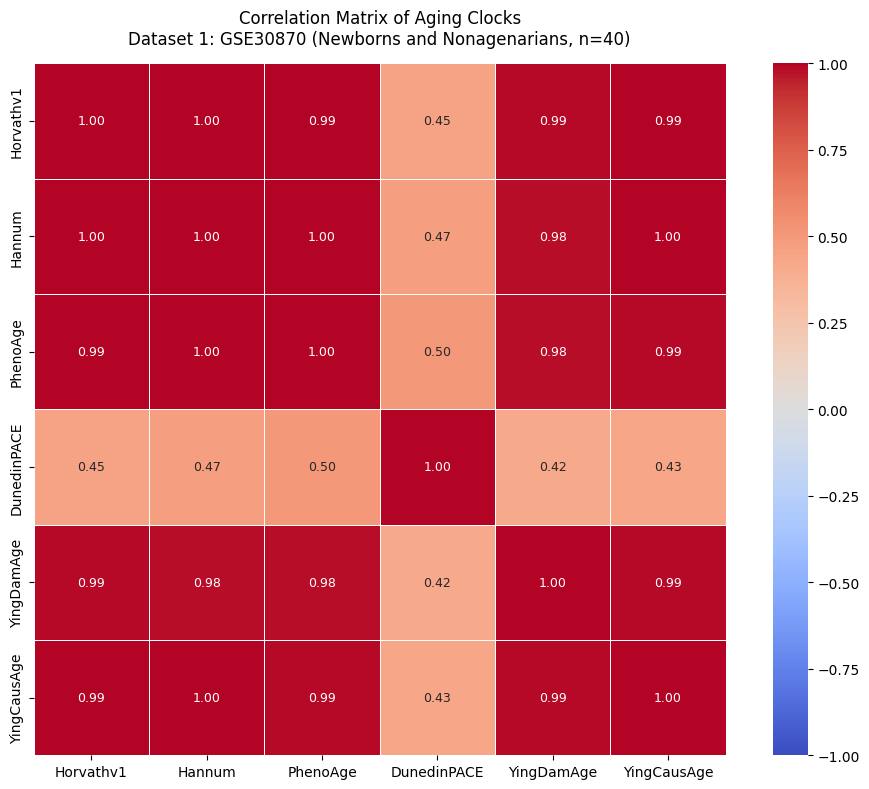

Saved: plot1_correlation_matrix_GSE30870.png


In [ ]:
valid_clocks1 = [c for c in CLOCK_NAMES if results1[c].notna().sum() > 3]

fig, ax = plt.subplots(figsize=(10, 8))
corr1 = results1[valid_clocks1].dropna().corr()

sns.heatmap(
    corr1,
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 9}
)
ax.set_title(
    "Correlation Matrix of Aging Clocks\nDataset 1: GSE30870 (Newborns and Nonagenarians, n=40)",
    fontsize=12, pad=14
)
plt.tight_layout()
plt.savefig("plot1_correlation_matrix_GSE30870.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot1_correlation_matrix_GSE30870.png")

## Step 6: Visualization 2 -- Clock Correlation Matrix (Dataset 2: GSE85311)

The same correlation heatmap on the exercise-aging cohort (n=38, narrower age range ~20-75 years).

A narrower age range is a harder prediction problem. Clock pairs that showed high correlation in GSE30870 may diverge here if their performance depends on a wide dynamic range. Patterns that persist across both datasets are more likely to reflect genuine biological relationships rather than artifacts of one study's design.

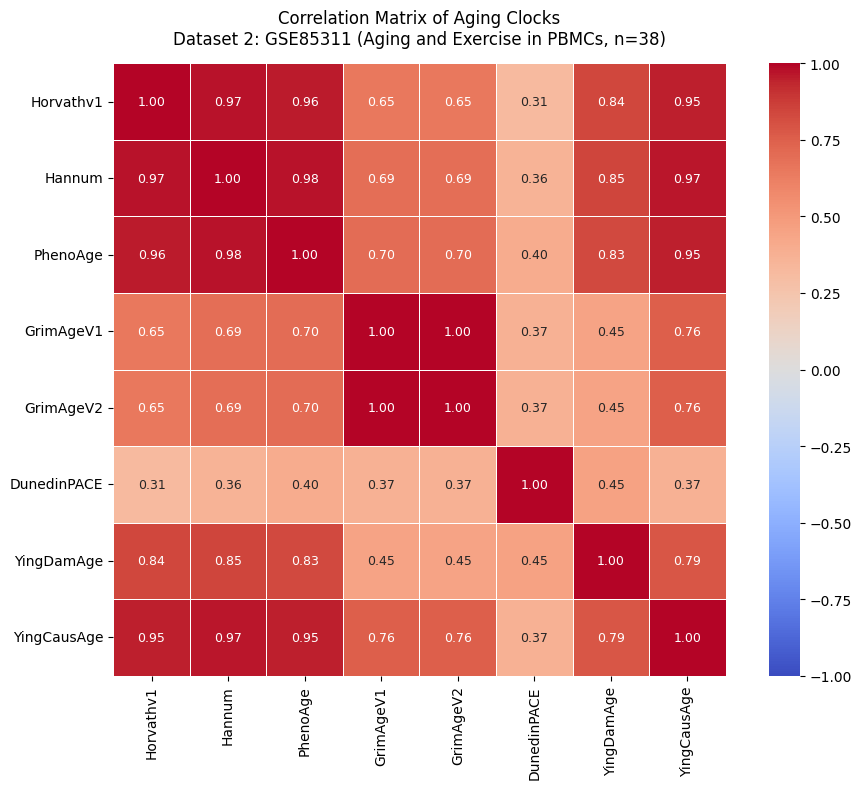

Saved: plot2_correlation_matrix_GSE85311.png


In [ ]:
valid_clocks2 = [c for c in CLOCK_NAMES if results2[c].notna().sum() > 3]

fig, ax = plt.subplots(figsize=(10, 8))
corr2 = results2[valid_clocks2].dropna().corr()

sns.heatmap(
    corr2,
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 9}
)
ax.set_title(
    "Correlation Matrix of Aging Clocks\nDataset 2: GSE85311 (Aging and Exercise in PBMCs, n=38)",
    fontsize=12, pad=14
)
plt.tight_layout()
plt.savefig("plot2_correlation_matrix_GSE85311.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot2_correlation_matrix_GSE85311.png")

## Step 7: Visualization 3 -- Age Deviation Heatmap (Dataset 1: GSE30870)

**Age deviation** = Predicted Age - Chronological Age

- Red: clock predicts the individual is biologically older than their calendar age
- Blue: clock predicts the individual is biologically younger
- Near zero: close agreement between clock and calendar age

Each column is one sample. Each row is one clock. Rows with strong red or blue bias across most columns indicate systematic over- or underestimation by that clock. Columns where clocks disagree (mixed red and blue) suggest complex biology in that individual that different clocks interpret differently.

DunedinPACE deviations are on a different scale and will appear distinctive from the year-based clocks.

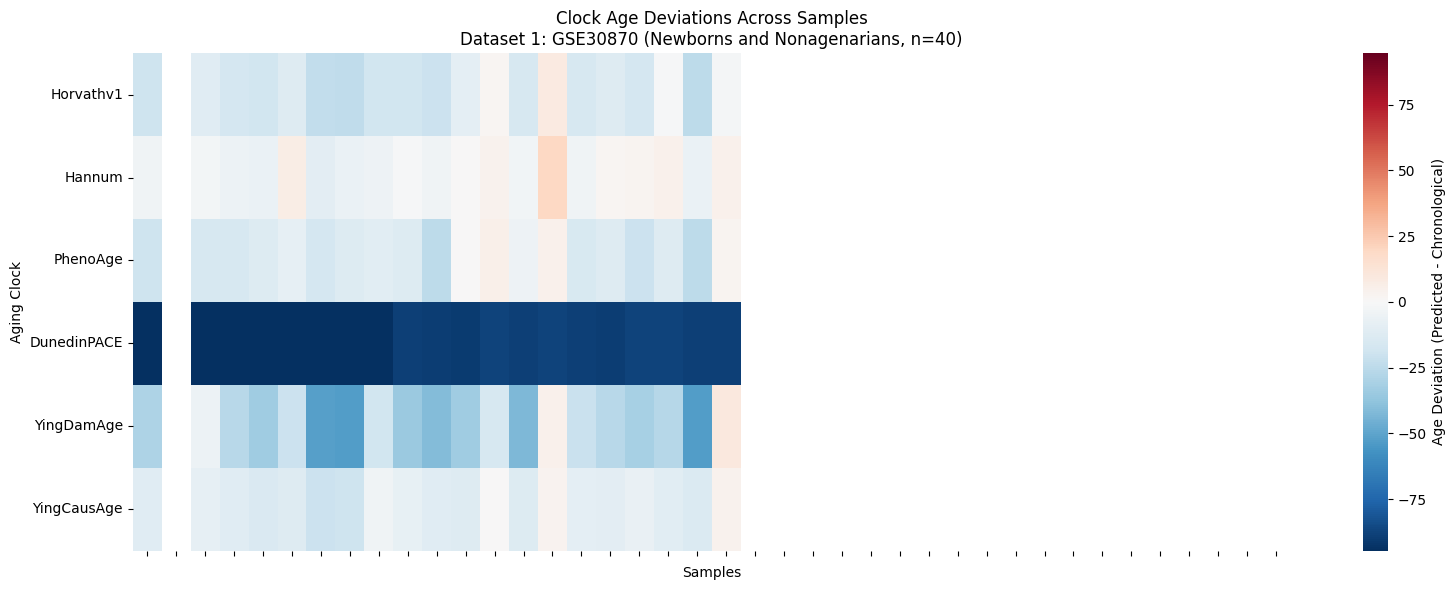

Saved: plot3_deviation_heatmap_GSE30870.png


In [ ]:
def make_deviation_heatmap(results_df, clock_list, title, filename):
    chron = results_df["Chronological_Age"]
    deviations = pd.DataFrame(index=results_df.index)
    for clock in clock_list:
        if clock in results_df.columns and results_df[clock].notna().sum() > 3:
            deviations[clock] = results_df[clock] - chron
    deviations = deviations.dropna(axis=1, how='all')
    abs_max = np.nanpercentile(np.abs(deviations.values), 95)
    fig, ax = plt.subplots(figsize=(max(14, len(deviations) * 0.4), 6))
    sns.heatmap(
        deviations.T,
        cmap="RdBu_r", center=0,
        vmin=-abs_max, vmax=abs_max,
        linewidths=0, ax=ax,
        cbar_kws={"label": "Age Deviation (Predicted - Chronological)"}
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Samples")
    ax.set_ylabel("Aging Clock")
    ax.set_xticklabels([])
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

make_deviation_heatmap(
    results1, CLOCK_NAMES,
    "Clock Age Deviations Across Samples\nDataset 1: GSE30870 (Newborns and Nonagenarians, n=40)",
    "plot3_deviation_heatmap_GSE30870.png"
)

## Step 8: Visualization 4 -- Age Deviation Heatmap (Dataset 2: GSE85311)

The same deviation heatmap on the exercise cohort.

Because GSE85311 includes older individuals with different exercise histories, this heatmap may reveal whether any clocks detect biological effects of aerobic training. Older exercisers who age more slowly biologically would appear as blue columns compared to age-matched sedentary controls, if the clock is sensitive to lifestyle effects.

Comparing the two heatmaps also reveals the magnitude and direction of systematic bias differences across cohorts.

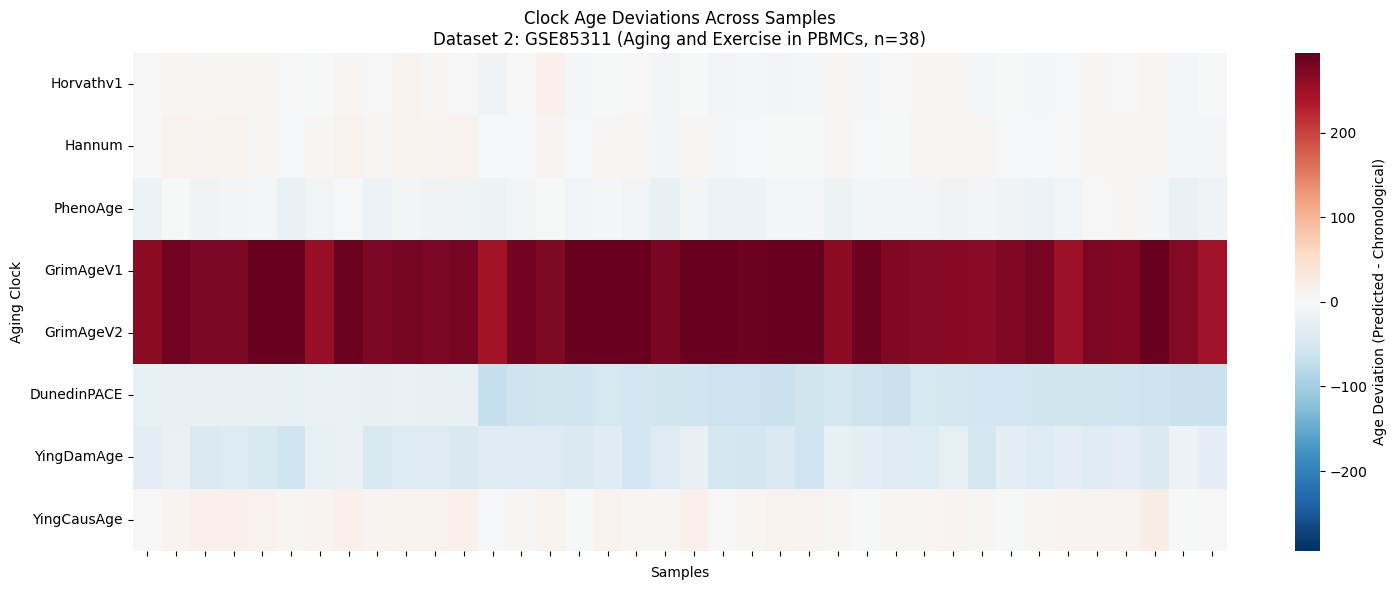

Saved: plot4_deviation_heatmap_GSE85311.png


In [ ]:
make_deviation_heatmap(
    results2, CLOCK_NAMES,
    "Clock Age Deviations Across Samples\nDataset 2: GSE85311 (Aging and Exercise in PBMCs, n=38)",
    "plot4_deviation_heatmap_GSE85311.png"
)

## Step 9: Visualization 5 -- Predicted vs. Chronological Age (Dataset 1: GSE30870)

A grid of scatter plots, one panel per clock:
- X-axis: chronological age
- Y-axis: predicted age or pace score
- Red dashed line: line of perfect agreement
- Pearson r: annotated per panel

| Pattern | Interpretation |
|---|---|
| Points along the red line | Accurate chronological age predictor |
| High r, line offset above/below | Systematic bias |
| Wide scatter, low r | Clock measures something distinct from calendar age |
| Flat band (DunedinPACE) | Normal; output is pace score not years |

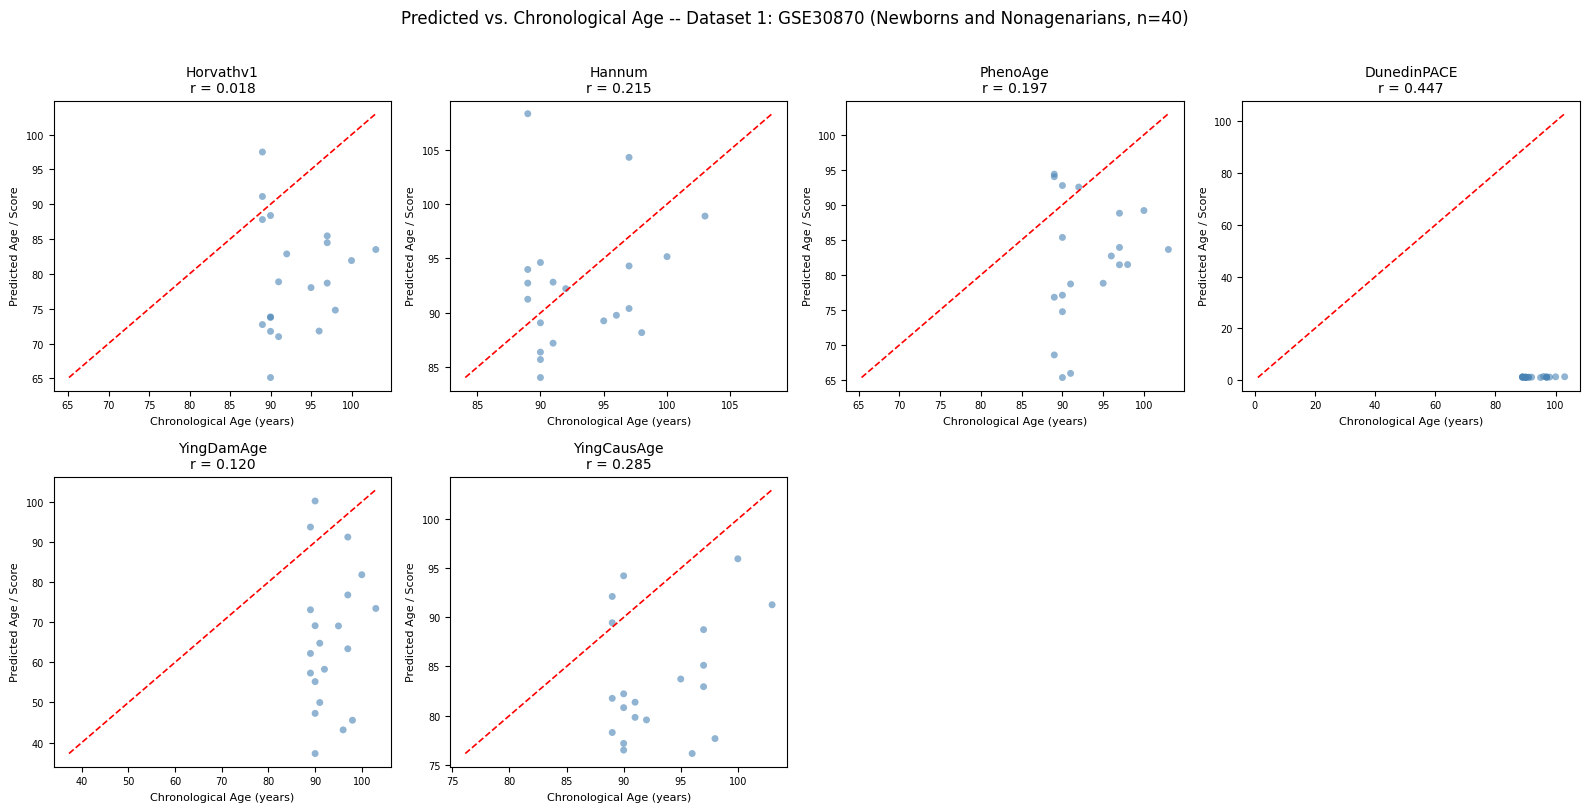

Saved: plot5_predicted_vs_chronological_GSE30870.png


In [ ]:
def make_scatter_grid(results_df, clock_list, title_prefix, filename):
    active = [c for c in clock_list if results_df[c].notna().sum() > 3]
    n = len(active)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
    axes = axes.flatten()
    for i, clock in enumerate(active):
        ax = axes[i]
        valid = results_df[["Chronological_Age", clock]].dropna()
        if valid.empty:
            ax.axis('off')
            continue
        x = valid["Chronological_Age"]
        y = valid[clock]
        ax.scatter(x, y, alpha=0.6, s=25, color="steelblue", edgecolors='none')
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.2)
        r = np.corrcoef(x, y)[0, 1]
        ax.set_title(f"{clock}\nr = {r:.3f}", fontsize=10)
        ax.set_xlabel("Chronological Age (years)", fontsize=8)
        ax.set_ylabel("Predicted Age / Score", fontsize=8)
        ax.tick_params(labelsize=7)
    for j in range(len(active), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title_prefix, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

make_scatter_grid(
    results1, CLOCK_NAMES,
    "Predicted vs. Chronological Age -- Dataset 1: GSE30870 (Newborns and Nonagenarians, n=40)",
    "plot5_predicted_vs_chronological_GSE30870.png"
)

## Step 10: Visualization 6 -- Predicted vs. Chronological Age (Dataset 2: GSE85311)

The same scatter grid on the exercise-aging cohort.

The narrower age range (~20-75 years) is a harder prediction problem, so Pearson r values will generally be lower than in GSE30870. Comparing r values between the two datasets reveals which clocks are robust across study designs versus which depend on a wide age distribution to perform well.

In [ ]:
make_scatter_grid(
    results2, CLOCK_NAMES,
    "Predicted vs. Chronological Age -- Dataset 2: GSE85311 (Aging and Exercise in PBMCs, n=38)",
    "plot6_predicted_vs_chronological_GSE85311.png"
)

## Step 11: Summary Statistics Table

Quantitative comparison across clocks and datasets:
- **n**: samples with valid predictions
- **Pearson r**: correlation between predicted and chronological age
- **MAE (yrs)**: mean absolute error in years
- **Mean Deviation**: average signed bias (positive = overestimates age)

MAE and Mean Deviation are not meaningful for DunedinPACE as its output is not in years.

In [14]:
def summary_table(results_df, label):
    rows = []
    for clock in CLOCK_NAMES:
        valid = results_df[["Chronological_Age", clock]].dropna()
        if len(valid) < 3:
            rows.append({"Clock": clock, "n": 0, "Pearson r": np.nan, "MAE (yrs)": np.nan, "Mean Deviation": np.nan})
            continue
        x = valid["Chronological_Age"]
        y = valid[clock]
        rows.append({"Clock": clock, "n": len(valid),
                     "Pearson r": round(np.corrcoef(x, y)[0, 1], 3),
                     "MAE (yrs)": round(np.mean(np.abs(y - x)), 2),
                     "Mean Deviation": round(np.mean(y - x), 2)})
    df = pd.DataFrame(rows).set_index("Clock")
    print(f"\n{label}")
    return df

summary1 = summary_table(results1, "Dataset 1: GSE30870")
display(summary1)
summary2 = summary_table(results2, "Dataset 2: GSE85311")
display(summary2)


Dataset 1: GSE30870


,n,Pearson r,MAE (yrs),Mean Deviation
Clock,,,,
Horvathv1,20,0.018,14.54,-13.48
Hannum,20,0.215,5.14,-0.71
PhenoAge,20,0.197,12.71,-11.34
GrimAgeV1,0,NaN,NaN,NaN
GrimAgeV2,0,NaN,NaN,NaN
DunedinPACE,20,0.447,91.98,-91.98
YingDamAge,20,0.120,28.99,-27.50
YingCausAge,20,0.285,10.19,-9.41



Dataset 2: GSE85311


,n,Pearson r,MAE (yrs),Mean Deviation
Clock,,,,
Horvathv1,38,0.958,4.27,-0.15
Hannum,38,0.960,5.02,2.24
PhenoAge,38,0.951,10.44,-10.13
GrimAgeV1,38,0.699,281.49,281.49
GrimAgeV2,38,0.699,281.49,281.49
DunedinPACE,38,0.318,46.60,-46.60
YingDamAge,38,0.850,37.78,-37.78
YingCausAge,38,0.949,7.55,7.16


## Step 12: Download All Output Files

Downloads all six plots. This function only works in Google Colab. In a local Jupyter environment the files are already in the working directory.

To save the notebook itself: **File -> Download -> Download .ipynb**

In [ ]:
output_files = [
    "plot1_correlation_matrix_GSE30870.png",
    "plot2_correlation_matrix_GSE85311.png",
    "plot3_deviation_heatmap_GSE30870.png",
    "plot4_deviation_heatmap_GSE85311.png",
    "plot5_predicted_vs_chronological_GSE30870.png",
    "plot6_predicted_vs_chronological_GSE85311.png",
]
try:
    from google.colab import files
    for f in output_files:
        files.download(f)
        print(f"Downloading: {f}")
    print("All files downloaded.")
except ImportError:
    import os
    print("Not in Colab. Files saved to working directory:")
    for f in output_files:
        print(f"  {f} -- {'found' if os.path.isfile(f) else 'not found'}")

In [13]:
results1.to_csv("results_GSE30870.csv", index=True)
results2.to_csv("results_GSE85311.csv", index=True)

try:
    from google.colab import files
    files.download("results_GSE30870.csv")
    files.download("results_GSE85311.csv")
    print("Both CSV files downloaded.")
except ImportError:
    print("Files saved to working directory.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Both CSV files downloaded.


---

## References

1. Horvath S. (2013). DNA methylation age of human tissues and cell types. *Genome Biology*, 14, R115.
2. Hannum G. et al. (2013). Genome-wide methylation profiles reveal quantitative views of human aging rates. *Molecular Cell*, 49(2), 359-367.
3. Levine M.E. et al. (2018). An epigenetic biomarker of aging for lifespan and healthspan. *Aging*, 10(4), 573-591.
4. Lu A.T. et al. (2019). DNA methylation GrimAge strongly predicts lifespan and healthspan. *Aging*, 11(2), 303-327.
5. Belsky D.W. et al. (2022). DunedinPACE, a DNA methylation biomarker of the pace of aging. *eLife*, 11, e73420.
6. Ying K. et al. (2024). Causally-interpretable random-intercept cross-lagged panel models explain aging clocks. *bioRxiv*.
7. Quach A. et al. (2017). GSE85311. Epigenetic clock analysis of diet, exercise, education, and lifestyle factors. *Aging*, 9(2), 419-446.
8. biolearn library: https://bio-learn.github.io/

---
*For clinical or publication use, additional quality control, normalization, and statistical validation are required.*